In [1]:
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from adjustText import adjust_text
from matplotlib.colors import LinearSegmentedColormap

%load_ext autoreload
%autoreload 2

sys.path.insert(0, "..")
from plasmidtools import examplots, helpers


Paths

In [2]:
DATA_DIR = Path("../data")
FIG_DIR = DATA_DIR / "figures"
ADDGENE_DIR = DATA_DIR / "addgene"
MANUAL_DIR = DATA_DIR / "manual_annotations"
PLASMID_FASTA = ADDGENE_DIR / "mammalian_plasmids_wrapped.fasta"
GBK_DIR = DATA_DIR / "genbank"


Pre-processed / pre-calculated data

In [3]:
plasmid_citations = (
    pl.read_csv(ADDGENE_DIR / "mammalian_plasmids.tsv", separator="\t")
    .join(pl.read_parquet(ADDGENE_DIR / "citations_addgene.parquet"), on="plasmid_id")
)

plasmid_stats = (
    pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_statistics.parquet")
    .join(plasmid_citations, on="sequence_id")
)

element_positions = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_elements.parquet")
element_citations = pl.read_parquet(ADDGENE_DIR / "citations_addgene_elements.parquet")
cre_annotation = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_cre_and_tss.parquet")

element_cre_overlap = (
    pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_element_cre_overlaps.parquet")
    .join(element_citations[["element_type", "element_name", "n_plasmids", "n_citations"]], left_on=["type", "name"], right_on=["element_type", "element_name"], how="left")
    .with_columns(pl.max_horizontal("tss_fwd_avg_signal", "tss_rev_avg_signal").alias("tss_avg_signal"))
)


Data to show plasmid examples

In [4]:
CREST_TILE_ENCOD = ADDGENE_DIR / "mammalian_plasmids_crest_encodings.parquet"
CREST_TILE_PREDS = ADDGENE_DIR / "mammalian_plasmids_crest_preds.parquet"
CELL_TYPES = ["HEK293T", "A549", "MRC5", "SHSY5Y", "K562", "GM12878", "Jurkat"]

PUFFIN_PREDS = ADDGENE_DIR / "mammalian_plasmids_puffin_preds.h5"

# Load CREST predictions
tile_encoding = pl.read_parquet(CREST_TILE_ENCOD)
cre_predictions = pl.read_parquet(CREST_TILE_PREDS)
n_crest_tiles = tile_encoding["tile_ids"].list.max().max() + 1
crest_pred_dct = {}
for cell in CELL_TYPES:
    tile_preds = np.full(n_crest_tiles, np.nan)
    tile_preds[cre_predictions["tile_ID"].to_numpy()] = cre_predictions[cell].to_numpy()
    crest_pred_dct[cell] = tile_preds

# Load Puffin indices
with h5py.File(PUFFIN_PREDS, "r") as h5f:
    puffin_feat_names = h5f.attrs["features"]
    puffin_fwd_idx = int(np.argwhere(puffin_feat_names == "FANTOM_CAGE fwd")[0, 0])
    puffin_rev_idx = int(np.argwhere(puffin_feat_names == "FANTOM_CAGE rev")[0, 0])


### Results

Definitions and search strategy are provided in teh [`README.md`](../data/README.md) ("Buffer CREs formal procedure").

Calculations are performed in the [`11_buffer_cres.py`](../scripts/11_buffer_cres.py) and [`12_buffer_cres_sequences.py`](../scripts/12_buffer_cres_sequences.py) scripts.

In [5]:
buffer_cres = pl.read_parquet(ADDGENE_DIR / "buffer_cres.parquet")  # individual instances
# buffer_cres["cre_type"].value_counts().sort("count")

buffer_sequences = pl.read_parquet(ADDGENE_DIR / "buffer_cres_sequences.parquet")  # aggregated by identical anchore sequences


**\# of Buffer CREs / TSSs per plasmid**

In [6]:
cres_per_plasmid = (
    buffer_cres.filter(pl.col("cre_type") == "CREST (HEK293T)")
    .group_by("gbk_name").agg(pl.len().alias("num_buffer_cres"))
)

tss_per_plasmid = (
    buffer_cres.filter(pl.col("cre_type").is_in(["Puffin (FANTOM_CAGE_fwd)", "Puffin (FANTOM_CAGE_rev)"]))
    .group_by("gbk_name").agg(pl.len().alias("num_buffer_tss"))
)

buffer_stats = (
    plasmid_stats
    .join(cres_per_plasmid, on="gbk_name", how="left")
    .join(tss_per_plasmid, on="gbk_name", how="left")
    .fill_null(strategy="zero")
    .with_columns(
        (pl.col("num_buffer_cres") * 1000 / pl.col("plasmid_length")).alias("num_buffer_cres_kbp"),
        (pl.col("num_buffer_tss") * 1000 / pl.col("plasmid_length")).alias("num_buffer_tss_kbp")
    )
)


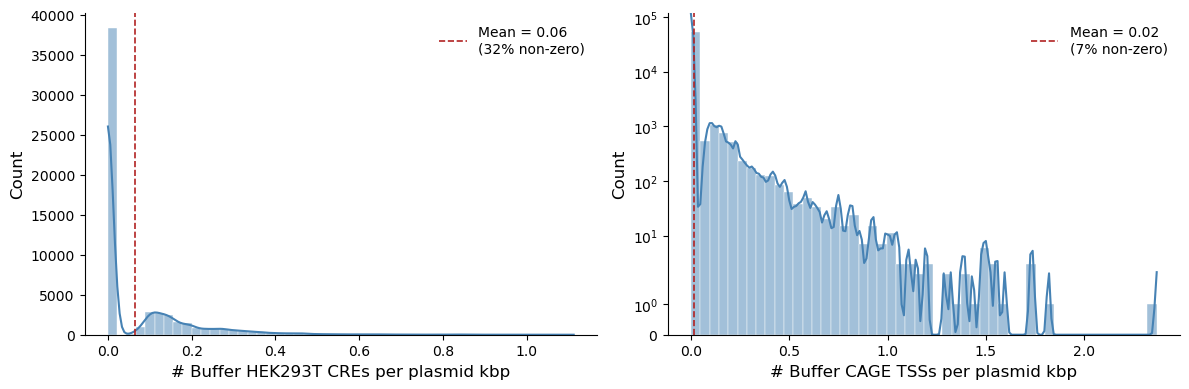

In [7]:
cols = ["num_buffer_cres_kbp", "num_buffer_tss_kbp"]
xlabels = ["# Buffer HEK293T CREs per plasmid kbp", "# Buffer CAGE TSSs per plasmid kbp"]

fig, axes = plt.subplots(figsize=(12, 4), ncols=2, layout="tight")

for ax, col, xlabel in zip(axes, cols, xlabels):
    data = buffer_stats[col].to_numpy()
    median = np.median(data)

    sns.histplot(
        data, bins=50,
        color="steelblue", edgecolor="white", linewidth=0.3,
        kde=True, line_kws={"linewidth": 1.5, "color": "firebrick"},
        ax=ax,
    )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Count", fontsize=12)

    pct_nonzero = 100 * (data > 0).mean()
    if median == 0:                                  # zero-inflated
        mean_val    = data.mean()
        vline_label = f"Mean = {mean_val:.2f}\n({pct_nonzero:.0f}% non-zero)"
        vline_x     = mean_val
    else:
        vline_label = f"Median = {median:.2f}\n({pct_nonzero:.0f}% non-zero)"
        vline_x     = median

    ax.axvline(vline_x, color="firebrick", linewidth=1.2,
               linestyle="--", label=vline_label)
    ax.legend(frameon=False, fontsize=10)

axes[1].set_yscale("symlog")

sns.despine()

**\# Unique buffer CRE (HEK293T) sequences**

In [8]:
activity_map = buffer_cres.select(["cre_raw_id", "cre_activity"])

median_activities = (
    buffer_sequences
    .select(["anchor_id", "cre_raw_ids"])
    .explode("cre_raw_ids")
    .join(activity_map, left_on="cre_raw_ids", right_on="cre_raw_id", how="left")
    .group_by("anchor_id")
    .agg(pl.col("cre_activity").median().alias("cre_activity"))
)

buffer_sequences = buffer_sequences.join(median_activities, on="anchor_id", how="left")


/scratch/6884984.1.p16/ipykernel_1645551/1134980459.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_tick_vals)


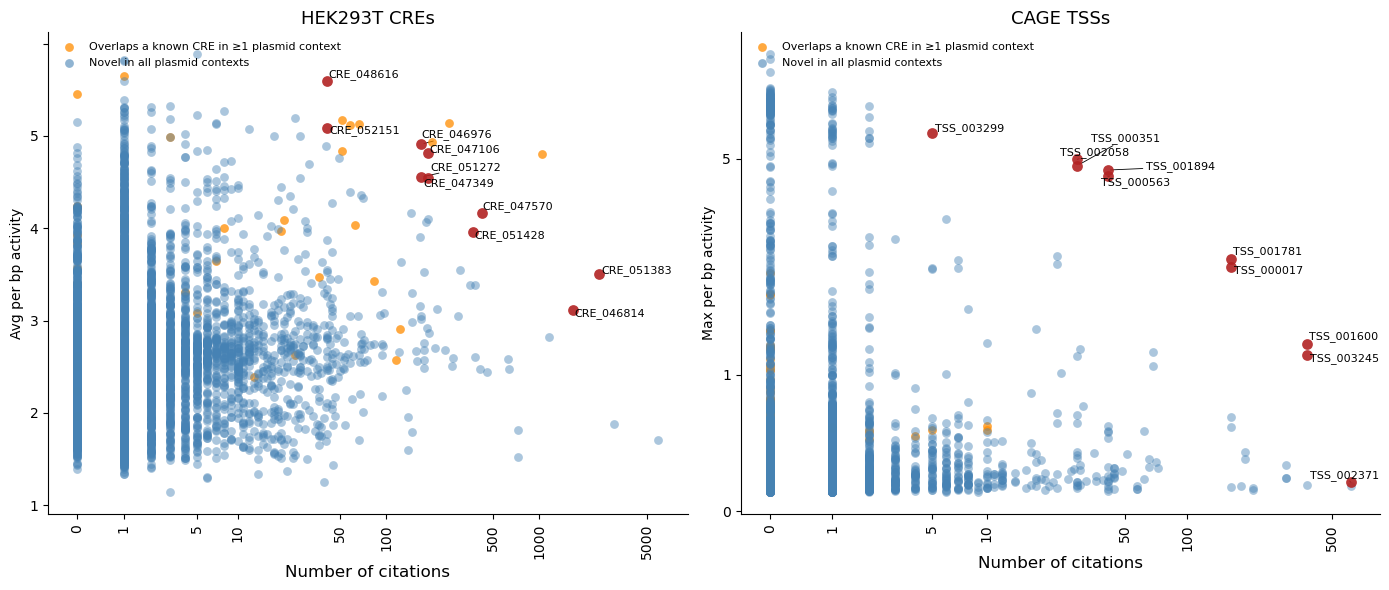

In [9]:
def plot_cre_scatter(ax, df, title, id_prefix: str, N=10, y_tick_vals=None, y_log=True):
    overlaps   = df["overlaps_known_cre"].to_numpy()
    novel_mask = ~overlaps

    x = df["n_citations"].to_numpy().astype(float)
    y = df["cre_activity"].to_numpy().astype(float)
    names = np.array([f"{id_prefix}_{anc_id.removeprefix('ANC_')}" for anc_id in df["anchor_id"]])

    xlog   = np.log1p(x)
    y_plot = np.log1p(y) if y_log else y

    # ── score and top-N from novel only ──────────────────────────────────────
    novel_indices   = np.where(novel_mask)[0]
    xlog_n, y_n     = xlog[novel_indices], y_plot[novel_indices]
    score           = xlog_n / (xlog_n.max() or 1) + y_n / (y_n.max() or 1)
    top_idx         = novel_indices[np.argsort(score)[-N:]]
    top_mask        = np.zeros(len(x), dtype=bool)
    top_mask[top_idx] = True

    # ── plot layers (back → front) ────────────────────────────────────────────
    ax.scatter(xlog[overlaps],               y_plot[overlaps],
               s=40, color="darkorange", alpha=0.75, linewidths=0, zorder=2)
    ax.scatter(xlog[novel_mask & ~top_mask], y_plot[novel_mask & ~top_mask],
               s=40, color="steelblue", alpha=0.45, linewidths=0, zorder=2)
    ax.scatter(xlog[top_mask], y_plot[top_mask],
               s=60, color="firebrick", alpha=0.9, linewidths=0, zorder=3)

    # ── legend ────────────────────────────────────────────────────────────────
    ax.scatter([], [], s=40, color="darkorange", alpha=0.75, linewidths=0,
               label="Overlaps a known CRE in ≥1 plasmid context")
    ax.scatter([], [], s=40, color="steelblue",  alpha=0.60, linewidths=0,
               label="Novel in all plasmid contexts")
    ax.legend(fontsize=8, frameon=False, loc="upper left")

    texts = [ax.text(xlog[i], y_plot[i], names[i], fontsize=8, color="black") for i in top_idx]
    adjust_text(texts, ax=ax, arrowprops={"arrowstyle": "-", "color": "black", "lw": 0.6})

    tick_vals = np.array([0, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000])
    xticks = tick_vals[tick_vals <= x.max()]
    ax.set_xticks(np.log1p(xticks))
    ax.set_xticklabels(xticks, rotation=90)
    ax.set_xlabel("Number of citations", fontsize=12)

    if y_tick_vals is not None:
        if y_log:
            ax.set_yticks(np.log1p(y_tick_vals))
            ax.set_yticklabels(y_tick_vals)
        else:
            ax.set_yticklabels(y_tick_vals)
    else:
        if y_log:
            yticks = tick_vals[tick_vals <= y.max()]
            ax.set_yticks(np.log1p(yticks))
            ax.set_yticklabels(yticks)

    ax.set_title(title, fontsize=13)


# ── datasets ──────────────────────────────────────────────────────────────
hek293t_cres = buffer_sequences.filter(pl.col("cre_type") == "CREST (HEK293T)")
cage_tss = buffer_sequences.filter(pl.col("cre_type").is_in(["Puffin (FANTOM_CAGE_fwd)", "Puffin (FANTOM_CAGE_rev)"]))

# ── figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(figsize=(14, 6), ncols=2, layout="tight")

plot_cre_scatter(axes[0], hek293t_cres, "HEK293T CREs", id_prefix="CRE",
                 y_tick_vals=np.arange(6), y_log=False)
axes[0].set_ylabel("Avg per bp activity")

plot_cre_scatter(axes[1], cage_tss, "CAGE TSSs", id_prefix="TSS")
axes[1].set_ylabel("Max per bp activity")

sns.despine()


**CRE (HEK293T) Example**

In [10]:
# cre_example = (
#     hek293t_cres
#     .filter((pl.col("n_citations") > 10) & (pl.col("n_citations") < 50))
#     .filter(pl.col("cre_activity") > 2.5)
#     .sort("cre_activity", descending=True)
# )["anchor_id"][9]

cre_example = "ANC_048063"

# select the instance in the most cited plasmid
cre_plasmids = hek293t_cres.filter(pl.col("anchor_id") == cre_example)["gbk_names"][0].to_numpy()
hit_positions = hek293t_cres.filter(pl.col("anchor_id") == cre_example)["positions"][0].to_numpy()
cre_raw_ids = hek293t_cres.filter(pl.col("anchor_id") == cre_example)["cre_raw_ids"][0].to_numpy()

most_cited = (
    plasmid_stats
    .filter(pl.col("gbk_name").is_in(cre_plasmids))
    .sort("n_citations", descending=True)
    .select("gbk_name").head(1).item()
)
most_cited_idxs = np.argwhere(cre_plasmids == most_cited)
ex_plasmid = cre_plasmids[most_cited_idxs][0].item()
ex_positions = hit_positions[most_cited_idxs].T[0]
print(f"Example plasmid: {ex_plasmid} @ positions {ex_positions}")

# plasmid_stats.filter(pl.col("gbk_name") == ex_plasmid)


Example plasmid: sequence-191758- @ positions [3532]


In [11]:
# Extract plasmid GBK to a separate file
COMBINED_GBK = ADDGENE_DIR / "mammalian_plasmids.gbk"
gbk_file = GBK_DIR / f"{ex_plasmid}.gbk"
helpers.extract_genbank_record_by_name(COMBINED_GBK, ex_plasmid, gbk_file)

# Plasmid CREST predictions
tile_ids_plasmid = tile_encoding.filter(pl.col("gbk_name") == ex_plasmid)["tile_ids"][0]
plasmid_crest_preds = {cell: preds[tile_ids_plasmid] for cell, preds in crest_pred_dct.items()}

# Plasmid Puffin predictions
with h5py.File(PUFFIN_PREDS, "r") as h5f:
    puffin_preds = h5f[ex_plasmid][:]
    puffin_fwd_preds = puffin_preds[puffin_fwd_idx]
    puffin_rev_preds = puffin_preds[puffin_rev_idx]

# Peaks (CREs and TSSs)
plasmid_peaks = cre_annotation.filter(pl.col("gbk_name") == ex_plasmid)
plasmid_crest_peaks = {cell: plasmid_peaks[f"CREST ({cell})"].to_list() for cell in CELL_TYPES}
plasmid_fwd_tss = plasmid_peaks["Puffin (FANTOM_CAGE_fwd)"].to_list()
plasmid_rev_tss = plasmid_peaks["Puffin (FANTOM_CAGE_rev)"].to_list()

# Buffer CRE peak
hek293t_buffer_ex = [[int(pos), int(pos) + 200] for pos in ex_positions]


Output file exists, exiting.


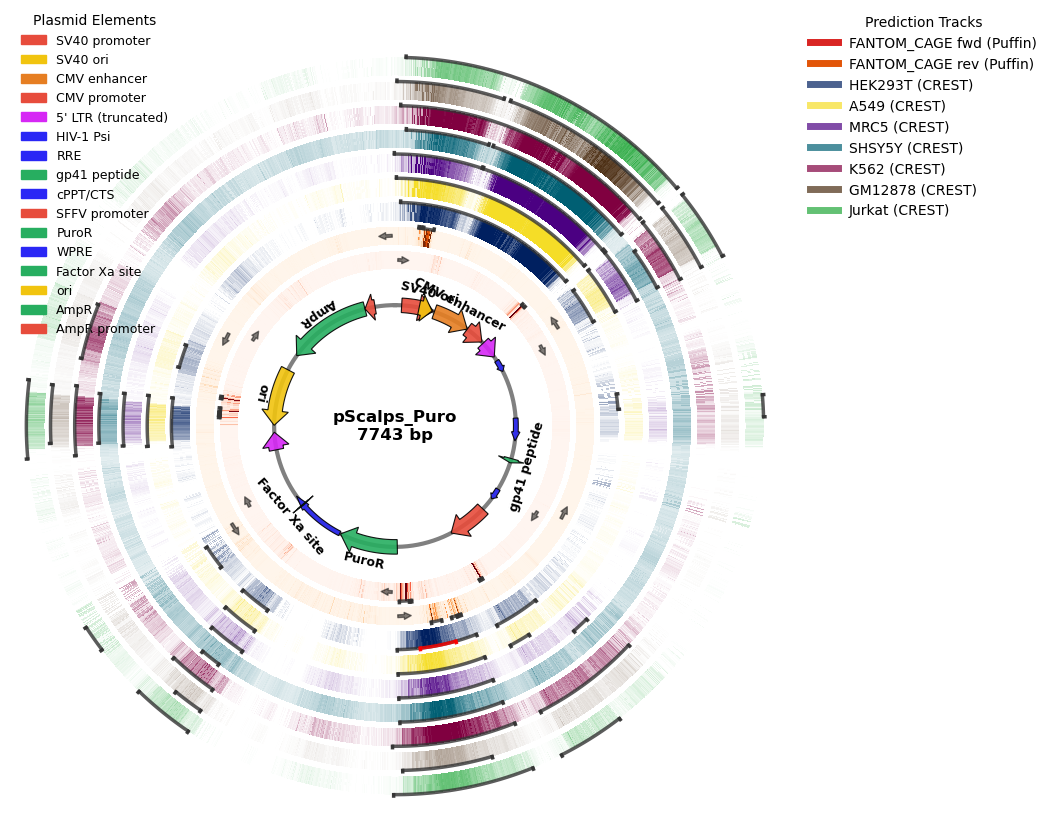

In [12]:
ax = examplots.plot_backbone(gbk_file)
track_width = 0.15  # thickness of each circular heatmap

# Plot Puffin tracks using red/orange sequential colormaps
examplots.plot_track_heatmap(ax, puffin_fwd_preds, cmap="Reds", track_base_radius=1.3, track_width=track_width, track_label="FANTOM_CAGE fwd (Puffin)", k_norm=0.25, direction="cw")
examplots.plot_peak_annotation(ax, plasmid_fwd_tss, seq_len=len(puffin_fwd_preds), track_base_radius=1.3, track_width=track_width)

examplots.plot_track_heatmap(ax, puffin_rev_preds, cmap="Oranges", track_base_radius=1.5, track_width=track_width, track_label="FANTOM_CAGE rev (Puffin)", k_norm=0.25, direction="ccw")
examplots.plot_peak_annotation(ax, plasmid_rev_tss, seq_len=len(puffin_rev_preds), track_base_radius=1.5, track_width=track_width)

# Custom colormaps: exact white at 0, moving to a rich, dark hue at maximum value
crest_cmaps = [
    LinearSegmentedColormap.from_list("c_blue", ["white", "#002060"]),  # Deep Royal Navy
    LinearSegmentedColormap.from_list("c_yellow", ["white", "#f5dd27"]),  # Yellow
    LinearSegmentedColormap.from_list("c_purple", ["white", "#4b0082"]),  # Deep Indigo/Purple
    LinearSegmentedColormap.from_list("c_teal", ["white", "#005f73"]),  # Dark Mediterranean Teal
    LinearSegmentedColormap.from_list("c_magenta", ["white", "#800040"]),  # Deep Wine/Plum Magenta
    LinearSegmentedColormap.from_list("c_brown", ["white", "#4a2c11"]),  # Dark Chocolate Brown
    LinearSegmentedColormap.from_list("c_green", ["white", "#21a639"])  # Forest Green
]

crest_base_r = 1.7  # Starting radius for the first CREST track

for i, cell in enumerate(CELL_TYPES):
    current_radius = crest_base_r + (i * (track_width + 0.05))  # 0.05 padding between rings
    examplots.plot_track_heatmap(ax, plasmid_crest_preds[cell], cmap=crest_cmaps[i], track_base_radius=current_radius, track_width=track_width, track_label=f"{cell} (CREST)", k_norm=6)
    examplots.plot_peak_annotation(ax, plasmid_crest_peaks[cell], seq_len=len(plasmid_crest_preds[cell]), track_base_radius=current_radius, track_width=track_width)
    if cell == "HEK293T":
        examplots.plot_peak_annotation(ax, hek293t_buffer_ex, seq_len=len(plasmid_crest_preds[cell]), track_base_radius=current_radius, track_width=track_width, color="#FF0000")

# Render legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.35, 1.05), title="Prediction Tracks", frameon=False)


**TSS (CAGE) Example**

In [48]:
tss_example = (
    cage_tss
    .filter((pl.col("n_citations") > 2) & (pl.col("n_citations") < 10))
    .filter(pl.col("cre_activity") > 0.5)
    .sort("cre_activity", descending=True)
)["anchor_id"][2]

In [49]:
# tss_example = "ANC_000552"

# select the instance in the most cited plasmid
cre_plasmids = cage_tss.filter(pl.col("anchor_id") == tss_example)["gbk_names"][0].to_numpy()
hit_positions = cage_tss.filter(pl.col("anchor_id") == tss_example)["positions"][0].to_numpy()
cre_raw_ids = cage_tss.filter(pl.col("anchor_id") == tss_example)["cre_raw_ids"][0].to_numpy()

most_cited = (
    plasmid_stats
    .filter(pl.col("gbk_name").is_in(cre_plasmids))
    .sort("n_citations", descending=True)
    .select("gbk_name").head(1).item()
)
most_cited_idxs = np.argwhere(cre_plasmids == most_cited)
ex_plasmid = cre_plasmids[most_cited_idxs][0].item()
ex_positions = hit_positions[most_cited_idxs].T[0]
print(f"Example plasmid: {ex_plasmid} @ positions {ex_positions}")

plasmid_stats.filter(pl.col("gbk_name") == ex_plasmid)


Example plasmid: sequence-137241- @ positions [755]


gbk_name,sequence_id,plasmid_length,backbone_length,total_insert_length,annotated_insert_length,putative_orf_insert_length,putative_noncoding_insert_length,n_feats,plasmid_id,plasmid_name,vector_type,backbone,inserts,download_status,citing_pmids,n_citations,status
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,str,str,str,list[str],i64,str
"""sequence-137241-""",137241,8091,6005,2218,0,1713,505,15,14906,"""HLA-A2/K^b""","""Mammalian Expression""","""pSV2neo""","""HLA-A2/K^b""","""200""","[""23658393"", ""31988324"", ""2477484""]",3,"""success"""


In [50]:
# Extract plasmid GBK to a separate file
COMBINED_GBK = ADDGENE_DIR / "mammalian_plasmids.gbk"
gbk_file = GBK_DIR / f"{ex_plasmid}.gbk"
helpers.extract_genbank_record_by_name(COMBINED_GBK, ex_plasmid, gbk_file)

# Plasmid CREST predictions
tile_ids_plasmid = tile_encoding.filter(pl.col("gbk_name") == ex_plasmid)["tile_ids"][0]
plasmid_crest_preds = {cell: preds[tile_ids_plasmid] for cell, preds in crest_pred_dct.items()}

# Plasmid Puffin predictions
with h5py.File(PUFFIN_PREDS, "r") as h5f:
    puffin_preds = h5f[ex_plasmid][:]
    puffin_fwd_preds = puffin_preds[puffin_fwd_idx]
    puffin_rev_preds = puffin_preds[puffin_rev_idx]

# Peaks (CREs and TSSs)
plasmid_peaks = cre_annotation.filter(pl.col("gbk_name") == ex_plasmid)
plasmid_crest_peaks = {cell: plasmid_peaks[f"CREST ({cell})"].to_list() for cell in CELL_TYPES}
plasmid_fwd_tss = plasmid_peaks["Puffin (FANTOM_CAGE_fwd)"].to_list()
plasmid_rev_tss = plasmid_peaks["Puffin (FANTOM_CAGE_rev)"].to_list()

# Buffer CRE peak
cage_buffer_ex = [[int(pos), int(pos) + 650] for pos in ex_positions]


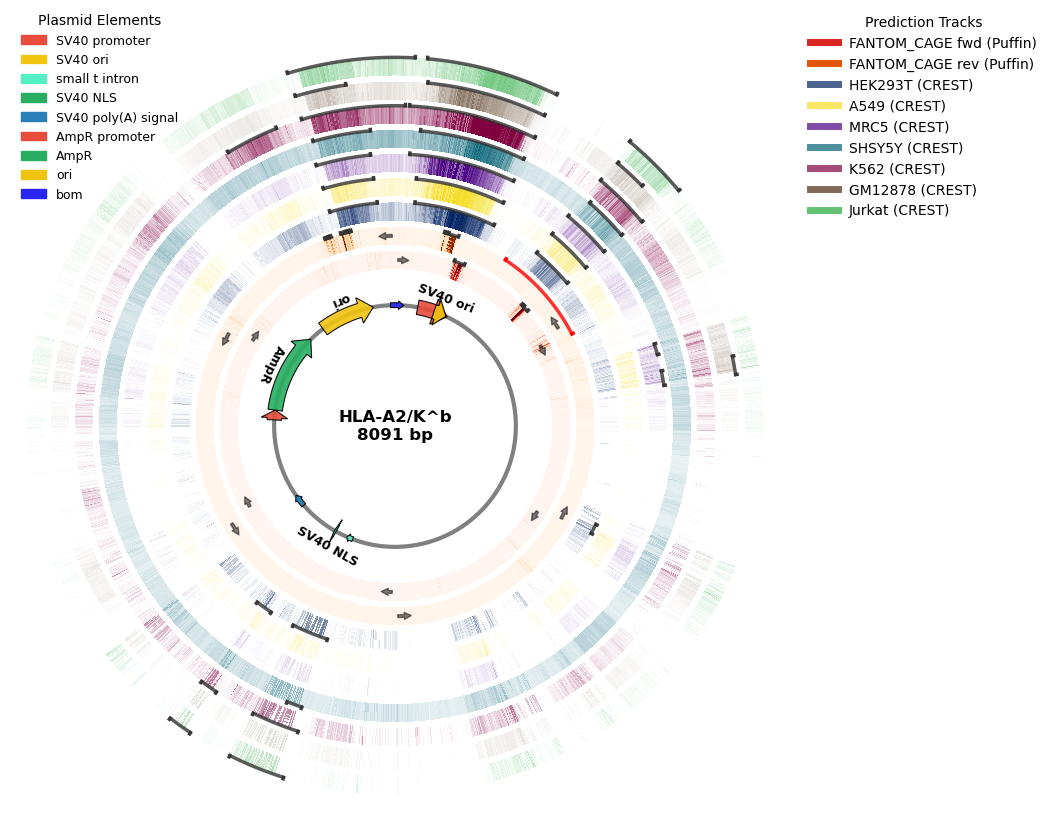

In [51]:
ax = examplots.plot_backbone(gbk_file)
track_width = 0.15  # thickness of each circular heatmap

# Plot Puffin tracks using red/orange sequential colormaps
examplots.plot_track_heatmap(ax, puffin_fwd_preds, cmap="Reds", track_base_radius=1.3, track_width=track_width, track_label="FANTOM_CAGE fwd (Puffin)", k_norm=0.25, direction="cw")
examplots.plot_peak_annotation(ax, plasmid_fwd_tss, seq_len=len(puffin_fwd_preds), track_base_radius=1.3, track_width=track_width)

examplots.plot_track_heatmap(ax, puffin_rev_preds, cmap="Oranges", track_base_radius=1.5, track_width=track_width, track_label="FANTOM_CAGE rev (Puffin)", k_norm=0.25, direction="ccw")
examplots.plot_peak_annotation(ax, plasmid_rev_tss, seq_len=len(puffin_rev_preds), track_base_radius=1.5, track_width=track_width)

examplots.plot_peak_annotation(ax, cage_buffer_ex, seq_len=len(puffin_rev_preds), track_base_radius=1.5, track_width=track_width, color="#FF0000")

# Custom colormaps: exact white at 0, moving to a rich, dark hue at maximum value
crest_cmaps = [
    LinearSegmentedColormap.from_list("c_blue", ["white", "#002060"]),  # Deep Royal Navy
    LinearSegmentedColormap.from_list("c_yellow", ["white", "#f5dd27"]),  # Yellow
    LinearSegmentedColormap.from_list("c_purple", ["white", "#4b0082"]),  # Deep Indigo/Purple
    LinearSegmentedColormap.from_list("c_teal", ["white", "#005f73"]),  # Dark Mediterranean Teal
    LinearSegmentedColormap.from_list("c_magenta", ["white", "#800040"]),  # Deep Wine/Plum Magenta
    LinearSegmentedColormap.from_list("c_brown", ["white", "#4a2c11"]),  # Dark Chocolate Brown
    LinearSegmentedColormap.from_list("c_green", ["white", "#21a639"])  # Forest Green
]

crest_base_r = 1.7  # Starting radius for the first CREST track

for i, cell in enumerate(CELL_TYPES):
    current_radius = crest_base_r + (i * (track_width + 0.05))  # 0.05 padding between rings
    examplots.plot_track_heatmap(ax, plasmid_crest_preds[cell], cmap=crest_cmaps[i], track_base_radius=current_radius, track_width=track_width, track_label=f"{cell} (CREST)", k_norm=6)
    examplots.plot_peak_annotation(ax, plasmid_crest_peaks[cell], seq_len=len(plasmid_crest_preds[cell]), track_base_radius=current_radius, track_width=track_width)
  
# Render legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.35, 1.05), title="Prediction Tracks", frameon=False)
